## Business Context

Company X is evaluating employee health insurance options and requires a deep understanding of its workforce demographics, risk profile, and coverage needs.

This analysis aims to identify key workforce characteristics that will influence healthcare utilization and plan selection.

## Data Overview

This analysis uses an employee-level dataset containing approximately 8,400 employees, including demographic, financial, and health risk indicators.

Key variables include age, salary, dependents, coverage tier, and utilization risk score.

## Dataset fields used in this analysis
- age
- salary
- job_level
- dependents_count
- coverage_tier
- chronic_condition_flag
- smoker_flag
- enrollment_status
- utilization_risk_score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

employees = pd.read_csv('/content/drive/MyDrive/EMP BEN PROJECT DATA/employer_health_plan_employee_level_dataset.csv')
companies = pd.read_csv('/content/drive/MyDrive/EMP BEN PROJECT DATA/employer_health_plan_dataset.csv')
claims = pd.read_csv('/content/drive/MyDrive/EMP BEN PROJECT DATA/employer_health_plan_employee_level_dataset.csv')

In [ ]:
employees = employees.copy()
employees.head()
employees.info()
employees.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8400 entries, 0 to 8399
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             8400 non-null   int64  
 1   company_id              8400 non-null   int64  
 2   company_name            8400 non-null   object 
 3   industry                8400 non-null   object 
 4   plan_type               8400 non-null   object 
 5   age                     8400 non-null   int64  
 6   salary                  8400 non-null   int64  
 7   job_level               8400 non-null   object 
 8   dependents_count        8400 non-null   int64  
 9   coverage_tier           8400 non-null   object 
 10  chronic_condition_flag  8400 non-null   int64  
 11  smoker_flag             8400 non-null   int64  
 12  enrollment_status       8400 non-null   object 
 13  utilization_risk_score  8400 non-null   float64
dtypes: float64(1), int64(7), object(6)
memor

,employee_id,company_id,company_name,industry,plan_type,age,salary,job_level,dependents_count,coverage_tier,chronic_condition_flag,smoker_flag,enrollment_status,utilization_risk_score
count,8400.000000,8400.000000,8400,8400,8400,8400.000000,8400.000000,8400,8400.000000,8400,8400.000000,8400.000000,8400,8400.000000
unique,NaN,NaN,60,10,6,NaN,NaN,4,NaN,4,NaN,NaN,2,NaN
top,NaN,NaN,Company_1,Logistics,PPO Gold,NaN,NaN,Mid,NaN,Employee Only,NaN,NaN,Enrolled,NaN
freq,NaN,NaN,140,980,1820,NaN,NaN,3078,NaN,3554,NaN,NaN,7547,NaN
mean,104200.500000,30.500000,NaN,NaN,NaN,36.188333,74887.468571,NaN,0.775714,NaN,0.225833,0.157857,NaN,0.320368
std,2425.015464,17.319133,NaN,NaN,NaN,9.864603,26525.947248,NaN,0.920940,NaN,0.418155,0.364629,NaN,0.151911
min,100001.000000,1.000000,NaN,NaN,NaN,21.000000,42000.000000,NaN,0.000000,NaN,0.000000,0.000000,NaN,0.115000
25%,102100.750000,15.750000,NaN,NaN,NaN,28.000000,54685.750000,NaN,0.000000,NaN,0.000000,0.000000,NaN,0.206000
50%,104200.500000,30.500000,NaN,NaN,NaN,36.000000,68850.500000,NaN,1.000000,NaN,0.000000,0.000000,NaN,0.275000
75%,106300.250000,45.250000,NaN,NaN,NaN,43.000000,87456.750000,NaN,1.000000,NaN,0.000000,0.000000,NaN,0.415250


In [ ]:
employees.isnull().sum()
employees.duplicated().sum()
employees = employees.drop_duplicates()

#Removed duplicate records to ensure accurate workforce counts.

## Workforce Summary

- The company has approximately 8,400 employees.
- The average employee age is 35, indicating a relatively young workforce.
- The average salary is $74,887, suggesting a mid-income employee base.
- Employees have an average of 0.77 dependents, indicating moderate family coverage demand.

Expecting a low-low-medium usage, employees are fairly young on average, non-smokers mostly, with a low chronic condition probability.









Workforce Summary Insights
## Key Workforce Insights

- The workforce is primarily composed of mid-career employees, suggesting moderate healthcare utilization.
- A meaningful portion of employees have dependents, increasing the importance of family-friendly coverage options.
- The presence of chronic conditions and elevated risk scores among certain segments indicates the need for plans with manageable out-of-pocket costs.
- Enrollment rates suggest that a majority of employees will participate in employer-sponsored plans, increasing total employer exposure.

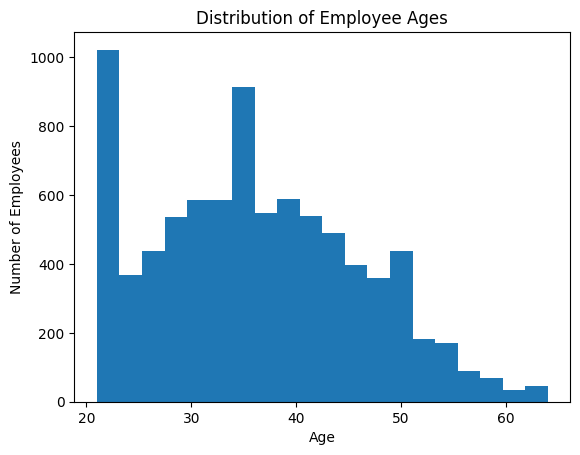

<Axes: xlabel='coverage_tier', ylabel='salary'>

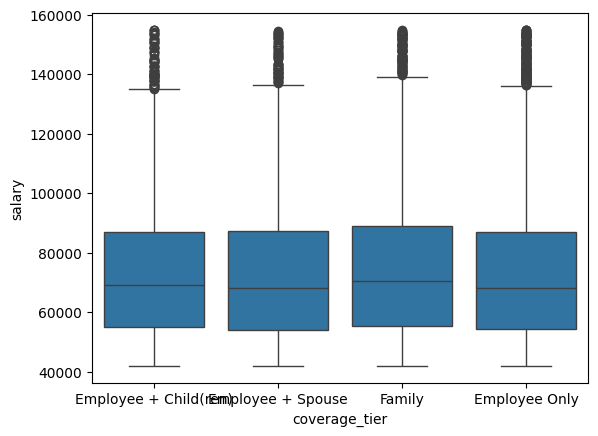

In [ ]:
employees["age"].plot(kind="hist", bins=20)
plt.title("Distribution of Employee Ages")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

sns.boxplot(x="coverage_tier", y="salary", data=employees)

In [ ]:
employees["age"].value_counts(ascending=False)



,count
age,
21,721
34,309
35,305
39,300
30,300
36,299
33,295
38,291
32,290


The workforce is concentrated between ages 22-40, indicating a primarily mid-career employee base with moderate expected healthcare utilization.

In [ ]:
employees["salary"].value_counts().sort_index()

,count
salary,
42000,1
42002,2
42009,2
42021,1
42033,1
...,...
154881,1
154892,1
154895,1


In [ ]:
employees["age"] = pd.cut(
    employees["age"],
    bins=[20,30,40,50,65],
    labels=["20s","30s","40s","50+"]
)
employees["salary"] = pd.cut(
    employees["salary"],
    bins=[0, 50000, 75000, 100000, 200000],
    labels=["Under 50K", "50K-75K", "75K-100K", "100K+"]
)

employees["risk_category"] = pd.cut(
    employees["utilization_risk_score"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)
employees["has_dependents"] = np.where(employees["dependents_count"] > 0, "Yes", "No")






In [ ]:
employees["has_dependents"].value_counts()

,count
has_dependents,
Yes,4387
No,4013


In [ ]:
employees["has_dependents"] = np.where(employees["dependents_count"] > 0, "Yes", "No")

employees["has_dependents"].value_counts(normalize=True) * 100

,proportion
has_dependents,
Yes,52.22619
No,47.77381


In [ ]:
employees["risk_category"].value_counts()

,count
risk_category,
Low,4772
Medium,3104
High,524


In [ ]:
#WORKFORCE SUMMARY METRICS


total_employees = employees["employee_id"].nunique()
avg_age = claims["age"].mean()
avg_salary = claims["salary"].mean()
avg_dependents = employees["dependents_count"].mean()
chronic_rate = employees["chronic_condition_flag"].mean()
smoker_rate = employees["smoker_flag"].mean()
enrollment_rate = (employees["enrollment_status"] == "Enrolled").mean()
avg_risk_score = employees["utilization_risk_score"].mean()

summary_metrics = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Average Age",
        "Average Salary",
        "Average Dependents",
        "Chronic Condition Rate",
        "Smoker Rate",
        "Enrollment Rate",
        "Average Utilization Risk Score"
    ],
    "Value": [
        total_employees,
        round(avg_age, 2),
        round(avg_salary, 2),
        round(avg_dependents, 2),
        round(chronic_rate * 100, 2),
        round(smoker_rate * 100, 2),
        round(enrollment_rate * 100, 2),
        round(avg_risk_score, 3)
    ]
})

summary_metrics

,Metric,Value
0,Total Employees,8400.00
1,Average Age,36.19
2,Average Salary,74887.47
3,Average Dependents,0.78
4,Chronic Condition Rate,22.58
5,Smoker Rate,15.79
6,Enrollment Rate,89.85
7,Average Utilization Risk Score,0.32


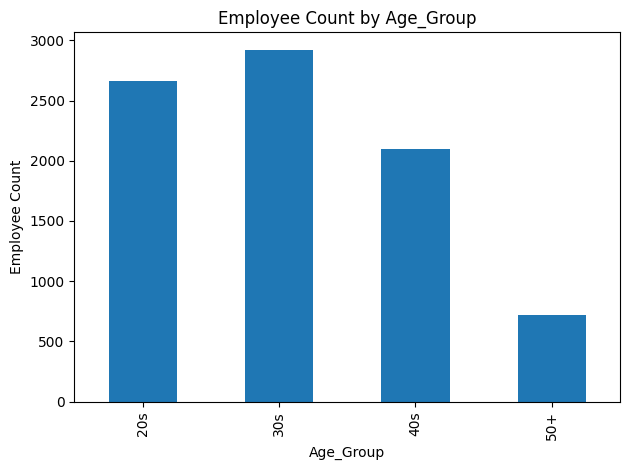

In [ ]:
#AGE DISTRIBUTION
employees["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Employee Count by Age_Group")
plt.xlabel("Age_Group")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()

The workforce is concentrated between ages 22–40, suggesting a relatively young/mid-career population with moderate healthcare utilization expectations.

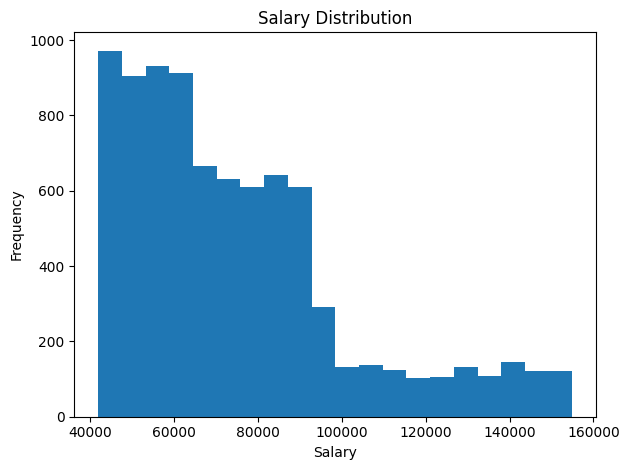

In [ ]:
#SALARY DISTRIBUTION
claims["salary"].plot(kind="hist", bins=20)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The salary distribution suggests a predominantly mid-income workforce, which may influence sensitivity to premium costs and out-of-pocket expenses.

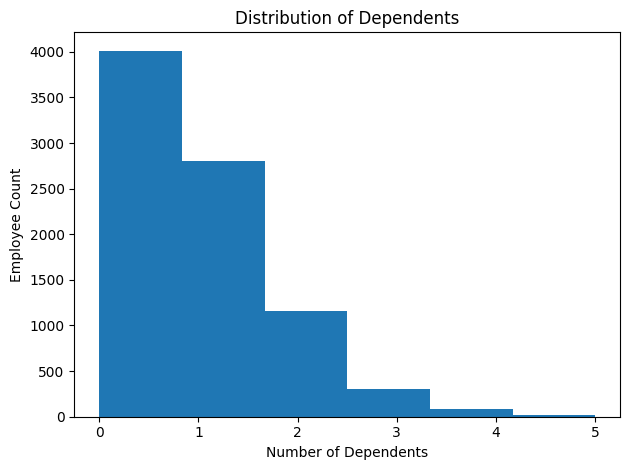

In [ ]:
#DEPENDENTS
employees["dependents_count"].plot(kind="hist", bins=6)
plt.title("Distribution of Dependents")
plt.xlabel("Number of Dependents")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()

A significant portion of employees have dependents, increasing the importance of family-friendly coverage options.

COVEREAGE AND ENROLLMENT ANALYSIS

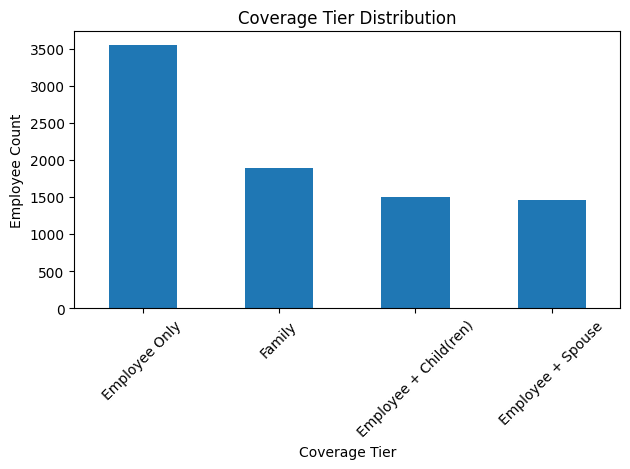

In [ ]:
employees["coverage_tier"].value_counts().plot(kind="bar")
plt.title("Coverage Tier Distribution")
plt.xlabel("Coverage Tier")
plt.ylabel("Employee Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
employees["enrollment_status"].value_counts(normalize=True) * 100

#High enrollment indicates strong demand for employer-sponsored benefits.

,proportion
enrollment_status,
Enrolled,89.845238
Waived,10.154762


High enrollment rates indicate strong reliance on employer-sponsored benefits, increasing the importance of selecting a cost-efficient plan structure.

In [ ]:
employees["coverage_tier"].value_counts()

,count
coverage_tier,
Employee Only,3554
Family,1895
Employee + Child(ren),1492
Employee + Spouse,1459


In [ ]:
employees.groupby("coverage_tier")["utilization_risk_score"].mean()

,utilization_risk_score
coverage_tier,
Employee + Child(ren),0.349891
Employee + Spouse,0.318284
Employee Only,0.288571
Family,0.358361


In [ ]:
employees.groupby("coverage_tier")["employee_id"].count().sort_values(ascending=False)

,employee_id
coverage_tier,
Employee Only,3554
Family,1895
Employee + Child(ren),1492
Employee + Spouse,1459


Most of the salaries lie in the 40K - 90K range with a few hundred employees earning upwards 100K most likely senior positions -- may have an affect on the family coverage tier frequencies.

HEALTH RISK ANALYSIS

In [ ]:
employees["chronic_condition_flag"].value_counts(normalize=True) * 100

,proportion
chronic_condition_flag,
0,77.416667
1,22.583333


In [ ]:
employees["smoker_flag"].value_counts(normalize=True) * 100

,proportion
smoker_flag,
0,84.214286
1,15.785714


In [ ]:
employees.groupby("age")["utilization_risk_score"].mean().round(3)

/tmp/ipykernel_502/4207703774.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employees.groupby("age")["utilization_risk_score"].mean().round(3)


,utilization_risk_score
age,
20s,0.262
30s,0.313
40s,0.368
50+,0.426


Older segments show a higher utilization score but still less than 50% showing a good average health across the age segments

In [ ]:
employees.groupby("coverage_tier")["utilization_risk_score"].mean().round(3)

,utilization_risk_score
coverage_tier,
Employee + Child(ren),0.350
Employee + Spouse,0.318
Employee Only,0.289
Family,0.358


In [ ]:
employees.groupby("job_level")["utilization_risk_score"].mean().round(3)

,utilization_risk_score
job_level,
Entry,0.323
Manager,0.320
Mid,0.321
Senior,0.316


Cross-analysis tables

In [ ]:
#Risk by age group and chronic condition
pd.pivot_table(
    employees,
    values="utilization_risk_score",
    index="age",
    columns="chronic_condition_flag",
    aggfunc="mean"
).round(3)

/tmp/ipykernel_502/2162437634.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


chronic_condition_flag,0,1
age,,
20s,0.192,0.490
30s,0.248,0.552
40s,0.300,0.603
50+,0.356,0.653


Each age group sees an increase in risk when a chronic condition is present naturally.

In [ ]:
employees["risk_category"].value_counts()

,count
risk_category,
Low,4772
Medium,3104
High,524


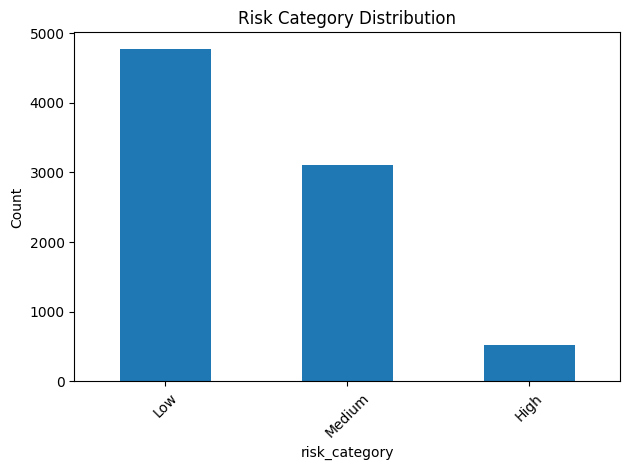

In [ ]:
employees["risk_category"].value_counts().plot(kind="bar")
plt.title("Risk Category Distribution")
plt.xlabel("risk_category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A meaningful portion of the workforce falls into low-to-medium risk categories, indicating that plan selection should balance affordability with adequate coverage.

In [ ]:
#Enrollment by coverage tier
pd.crosstab(
    employees["coverage_tier"],
    employees["enrollment_status"],
    normalize="index"
).round(3)

enrollment_status,Enrolled,Waived
coverage_tier,,
Employee + Child(ren),0.898,0.102
Employee + Spouse,0.894,0.106
Employee Only,0.900,0.100
Family,0.899,0.101


In [ ]:
#Average salary by job level
claims.groupby("job_level")["salary"].mean().round(2)

,salary
job_level,
Entry,75105.40
Manager,74693.66
Mid,74372.56
Senior,75489.49


In [ ]:
#Identify priority employee segments
high_risk_employees = employees[employees["utilization_risk_score"] >= 0.60]
high_risk_employees[[
    "employee_id", "age", "salary", "coverage_tier",
    "dependents_count", "chronic_condition_flag",
    "smoker_flag", "utilization_risk_score"
]].head()



,employee_id,age,salary,coverage_tier,dependents_count,chronic_condition_flag,smoker_flag,utilization_risk_score
0,100001,40s,100K+,Employee + Child(ren),1,1,0,0.608
8,100009,50+,50K-75K,Employee + Spouse,1,1,0,0.635
9,100010,50+,100K+,Employee Only,0,1,0,0.617
33,100034,40s,75K-100K,Family,2,1,0,0.610
40,100041,30s,75K-100K,Employee Only,0,1,1,0.625


In [ ]:
high_risk_summary = high_risk_employees.groupby("coverage_tier")["employee_id"].count().sort_values(ascending=False)
high_risk_summary

,employee_id
coverage_tier,
Family,176
Employee + Child(ren),140
Employee Only,127
Employee + Spouse,84


## Workforce In-depth Insights

- The workforce is primarily concentrated in the 30s age range.
- A significant share of employees have 0-2 dependents, which suggests strong demand for family-friendly coverage.
- The chronic condition rate is 23%, indicating that plan richness and out-of-pocket exposure will matter.
- Enrollment appears highest among employees in the 'Family' coverage tier.
- Higher utilization risk is concentrated in 50+ age groups, which may favor broader coverage options over high-deductible plans.

## Workforce Conclusion

The workforce profile indicates a diverse employee population with varying healthcare needs and risk levels. Employees with dependents and higher utilization risk will likely require more comprehensive coverage, while lower-risk employees may prioritize lower premiums.

These insights will guide the next phase of analysis focused on benchmarking Company X against industry standards and evaluating optimal plan structures.